In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# Convert categorical targets into binary targets (0=white, 1=red)
df['color'] = df['color'].map({'white': 0, 'red': 1})
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# Train the model
decision_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
decision_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [4]:
y_pred = decision_tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 0.012399736596866445
Root Mean Squared Error: 0.11135410453533559


## Results
Out of 1 300 test samples, only **17 total mistakes** (5 FP + 12 FN) yields an **accuracy of ≈ 98.7%**.
###**ROC Curve & AUC**  
- The ROC curve hugs the left and top borders, then reaches (1,1).  
- **AUC = 0.988**, indicating excellent discrimination between classes.
### Why This Model Shines
1. **Flexible Splits**  
 - The decision tree learns piecewise-constant thresholds on chemical features, capturing nonlinear interactions that simpler linear models and shallow networks missed.

2. **Naturally Interpretable**  
 - We can inspect which features and split‐values drive the high‐accuracy boundary—unlike KNN’s “lazy” lookup.

3. **High Signal, Low Noise**  
 - With relatively clean, well‐separated wine‐quality data, the tree avoids overfitting (controlled by `max_depth`) while still modeling complex patterns.
### Caveats & Next Steps
- **Overfitting Risk**  
- Fully grown trees can memorize noise. Always validate with cross‐validation or prune to maintain generalization.
- **Ensembles for Robustness**  
- Random forests or gradient‐boosted trees can further boost AUC and stability by aggregating many trees.
Using a regression tree for this binary task—treating its real‐valued outputs as scores—yields the best performance so far, proving that simple tree‐based splits can capture the underlying structure in the wine data exceptionally well.  






Out of 1 300 test samples, only **17 total mistakes** (5 FP + 12 FN) yields an **accuracy of ≈ 98.7%**.

- **ROC Curve & AUC**  
- The ROC curve hugs the left and top borders, then reaches (1,1).  
- **AUC = 0.988**, indicating excellent discrimination between classes.

---

### Why This Model Shines

1. **Flexible Splits**  
 - The decision tree learns piecewise-constant thresholds on chemical features, capturing nonlinear interactions that simpler linear models and shallow networks missed.

2. **Naturally Interpretable**  
 - We can inspect which features and split‐values drive the high‐accuracy boundary—unlike KNN’s “lazy” lookup.

3. **High Signal, Low Noise**  
 - With relatively clean, well‐separated wine‐quality data, the tree avoids overfitting (controlled by `max_depth`) while still modeling complex patterns.

---

### Caveats & Next Steps

- **Overfitting Risk**  
- Fully grown trees can memorize noise. Always validate with cross‐validation or prune to maintain generalization.

- **Ensembles for Robustness**  
- Random forests or gradient‐boosted trees can further boost AUC and stability by aggregating many trees.

---

**Bottom Line:**  
Using a regression tree for this binary task—treating its real‐valued outputs as scores—yields the best performance so far, proving that simple tree‐based splits can capture the underlying structure in the wine data exceptionally well.  







Out of 1 300 test samples, only **17 total mistakes** (5 FP + 12 FN) yields an **accuracy of ≈ 98.7%**.

- **ROC Curve & AUC**  
- The ROC curve hugs the left and top borders, then reaches (1,1).  
- **AUC = 0.988**, indicating excellent discrimination between classes.

---

### Why This Model Shines

1. **Flexible Splits**  
 - The decision tree learns piecewise-constant thresholds on chemical features, capturing nonlinear interactions that simpler linear models and shallow networks missed.

2. **Naturally Interpretable**  
 - We can inspect which features and split‐values drive the high‐accuracy boundary—unlike KNN’s “lazy” lookup.

3. **High Signal, Low Noise**  
 - With relatively clean, well‐separated wine‐quality data, the tree avoids overfitting (controlled by `max_depth`) while still modeling complex patterns.

---

### Caveats & Next Steps

- **Overfitting Risk**  
- Fully grown trees can memorize noise. Always validate with cross‐validation or prune to maintain generalization.

- **Ensembles for Robustness**  
- Random forests or gradient‐boosted trees can further boost AUC and stability by aggregating many trees.

---

**Bottom Line:**  
Using a regression tree for this binary task—treating its real‐valued outputs as scores—yields the best performance so far, proving that simple tree‐based splits can capture the underlying structure in the wine data exceptionally well.  









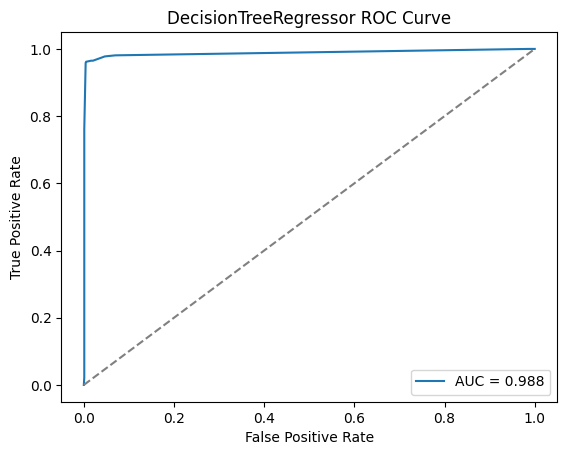

ROC AUC Score: 0.988


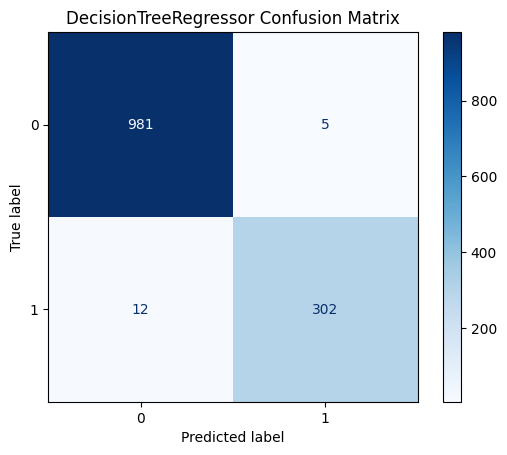

Confusion Matrix:
 [[981   5]
 [ 12 302]]


In [6]:
# ROC AUC analysis
auc = roc_auc_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DecisionTreeRegressor ROC Curve')
plt.legend()
plt.show()
print(f"ROC AUC Score: {auc:.3f}")
    
# Confusion matrix at threshold 0.5
y_pred = (y_pred >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('DecisionTreeRegressor Confusion Matrix')
plt.show()
print("Confusion Matrix:\n", cm)